In [10]:
from pyinaturalist import get_observations, get_taxa
import json
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Search specifically for ray-finned fish (taxon_id=47178) 
# in California/Pacific coast (place_id=14 is California)
results = get_taxa(
    q="",
    taxon_id=47178,  # Actinopterygii - ray-finned fish
    place_id=14,     # California
    rank="species",
    per_page=50,
    order_by="observations_count",
    order="desc"
)

for taxon in results['results']:
    obs_count = taxon.get('observations_count', 0)
    common = taxon.get('preferred_common_name', 'no common name')
    print(f"{taxon['name']} - {common} - {obs_count} observations")

Lepomis macrochirus - Bluegill - 59109 observations
Micropterus nigricans - Largemouth Bass - 39791 observations
Cyprinus carpio - European Carp - 32714 observations
Oncorhynchus mykiss - Rainbow Trout - 24753 observations
Cyprinus rubrofuscus - Amur Carp - 21971 observations
Gambusia affinis - Western Mosquitofish - 19938 observations
Lepomis cyanellus - Green Sunfish - 19599 observations
Lepomis gibbosus - Pumpkinseed - 17906 observations
Micropterus dolomieu - Smallmouth Bass - 17251 observations
Thamnaconus degeni - Bluefin Leatherjacket - 17227 observations
Carassius auratus - Goldfish - 16297 observations
Gambusia holbrooki - Eastern Mosquitofish - 16004 observations
Salmo trutta - Brown Trout - 15871 observations
Semotilus atromaculatus - Creek Chub - 13856 observations
Esox lucius - Northern Pike - 13615 observations
Salvelinus fontinalis - Brook Trout - 12174 observations
Ictalurus punctatus - Channel Catfish - 11279 observations
Zanclus cornutus - Moorish Idol - 11007 observa

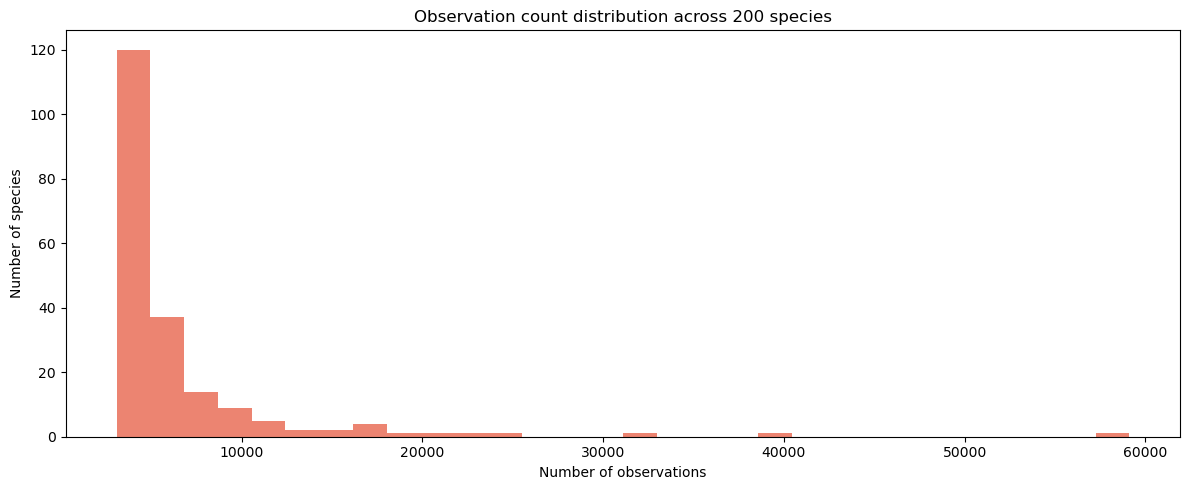

Min observations: 3086
Max observations: 59109
Median observations: 4465
Species with 1000+: 200
Species with 2000+: 200


In [11]:
counts = [s['count'] for s in qualified]
names = [s['common'] if s['common'] != 'no common name' else s['name'] for s in qualified]

plt.figure(figsize=(12, 5))
plt.hist(counts, bins=30, color='#e8664d', alpha=0.8)
plt.xlabel('Number of observations')
plt.ylabel('Number of species')
plt.title('Observation count distribution across 200 species')
plt.tight_layout()
plt.savefig('../outputs/species_distribution.png')
plt.show()

print(f"Min observations: {min(counts)}")
print(f"Max observations: {max(counts)}")
print(f"Median observations: {np.median(counts):.0f}")
print(f"Species with 1000+: {sum(1 for c in counts if c >= 1000)}")
print(f"Species with 2000+: {sum(1 for c in counts if c >= 2000)}")

In [12]:
# Filter to species that have a common name (more likely well-known/common species)
common_species = [s for s in qualified if s['common'] != 'no common name']

print(f"Species with common names: {len(common_species)}")
print(f"\nTop 30 by observation count:")
for s in sorted(common_species, key=lambda x: x['count'], reverse=True)[:30]:
    print(f"{s['common']:40} {s['name']:35} {s['count']:,}")

Species with common names: 200

Top 30 by observation count:
Bluegill                                 Lepomis macrochirus                 59,109
Largemouth Bass                          Micropterus nigricans               39,791
European Carp                            Cyprinus carpio                     32,714
Rainbow Trout                            Oncorhynchus mykiss                 24,753
Amur Carp                                Cyprinus rubrofuscus                21,971
Western Mosquitofish                     Gambusia affinis                    19,938
Green Sunfish                            Lepomis cyanellus                   19,599
Pumpkinseed                              Lepomis gibbosus                    17,906
Smallmouth Bass                          Micropterus dolomieu                17,251
Bluefin Leatherjacket                    Thamnaconus degeni                  17,227
Goldfish                                 Carassius auratus                   16,297
Eastern Mosquit

In [15]:
results = get_taxa(
    q="mackerel",
    taxon_id=47178,
    rank="species",
    per_page=20
)

for taxon in results['results']:
    print(taxon['name'], '-', taxon.get('preferred_common_name', 'no common name'), '-', taxon.get('observations_count', 0))

Caranx sexfasciatus - Bigeye Trevally - 2843
Pomatomus saltatrix - Bluefish - 2686
Trachurus novaezelandiae - Yellowtail Scad - 2070
Caranx ignobilis - Giant Trevally - 1946
Scomber scombrus - Atlantic Mackerel - 1307
Scomberomorus maculatus - Atlantic Spanish Mackerel - 871
Rastrelliger kanagurta - Longjaw Mackerel - 653
Scomber japonicus - Pacific Chub Mackerel - 607
Scomberomorus commerson - Narrow-banded Spanish Mackerel - 592
Acanthocybium solandri - Wahoo - 495
Euthynnus affinis - Mackerel Tuna - 420
Scomberomorus regalis - Cero - 393
Decapterus macarellus - Mackerel Scad - 372
Trachurus trachurus - Atlantic Horse Mackerel - 334
Scomberomorus cavalla - King Mackerel - 317
Scomberomorus tritor - West African Spanish Mackerel - 306
Trachurus symmetricus - Pacific Jack Mackerel - 300
Scomberomorus sierra - Sierra Mackerel - 263
Rastrelliger chrysozonus - Golden-striped Mackerel - 253
Scomber colias - Atlantic Chub Mackerel - 245


In [16]:
# Add Pacific mackerel species manually
extra_species = [
    {'name': 'Scomber japonicus', 'common': 'Pacific Chub Mackerel', 'count': 607, 'taxon_id': None},
    {'name': 'Trachurus symmetricus', 'common': 'Pacific Jack Mackerel', 'count': 300, 'taxon_id': None},
]

# Get their taxon IDs
for species in extra_species:
    result = get_taxa(q=species['name'], rank="species", per_page=1)
    if result['results']:
        species['taxon_id'] = result['results'][0]['id']
        print(f"{species['common']} - taxon_id: {species['taxon_id']}")

# Append to qualified list
qualified.extend(extra_species)
print(f"\nTotal species now: {len(qualified)}")

Pacific Chub Mackerel - taxon_id: 69840
Pacific Jack Mackerel - taxon_id: 114274

Total species now: 202


In [17]:
# Filter to species with common names only
final_species = [s for s in qualified if s['common'] != 'no common name']

print(f"Final species count: {len(final_species)}")
print(f"\nFull list:")
for i, s in enumerate(final_species, 1):
    print(f"{i:3}. {s['common']:40} {s['name']:35} {s['count']:,}")

Final species count: 202

Full list:
  1. Bluegill                                 Lepomis macrochirus                 59,109
  2. Largemouth Bass                          Micropterus nigricans               39,791
  3. European Carp                            Cyprinus carpio                     32,714
  4. Rainbow Trout                            Oncorhynchus mykiss                 24,753
  5. Amur Carp                                Cyprinus rubrofuscus                21,971
  6. Western Mosquitofish                     Gambusia affinis                    19,938
  7. Green Sunfish                            Lepomis cyanellus                   19,599
  8. Pumpkinseed                              Lepomis gibbosus                    17,906
  9. Smallmouth Bass                          Micropterus dolomieu                17,251
 10. Bluefin Leatherjacket                    Thamnaconus degeni                  17,227
 11. Goldfish                                 Carassius auratus          